# One Factor Heath-Jarrow-Morton Model

This notebook implements the one-factor HJM procedure described in Shreve, *Stochastic Calculus for Finance II*.

## Scope and Prerequisites

This notebook gives a self-contained implementation-level introduction to the one-factor Heath-Jarrow-Morton model. Financial quantities, modeling assumptions, and numerical methods are introduced as they are utilized.

This notebook assumes familiarity with basic calculus, probability, and linear algebra. The measure-theoretic construction of Brownian motion and derivation of the risk-neutral measure alongside other techniques used in the background are outside of its scope.

## Zero Coupon Bonds and Forward Rates

For the purposes of this notebook, a zero-coupon bond with maturity $T$ pays one unit of currency at time $T$. Its price at time $t$ is denoted by $B(t, T)$.

The continuously compounded forward rate $f(t, T)$ (per Shreve) is defined by

$$
    f(t, T) = -\frac{\partial}{\partial T} \log B(t, T).
$$

Equivalently, 

$$
    B(t, T) = \exp\left(-\int_t^T f(t, u) \,du \right).
$$

In this notebook, we will observe $f(t, T)$ at different observation times $t$ and maturity/time horizon $T$.

Precisely:
- $t$ is the time of observation of the curve
- $T$ is the terminal maturity
- $\tau = T-t$ is the time to maturity from observation

For example, $f(2, 5)$ would represent the forward rate observed 2 years after the model starts for a maturity 5 years after the model starts; there are 3 years left until maturity.

## The HJM Modeling Approach

HJM models the entire evolution of the entire forward curve. For every fixed maturity $T$, the corresponding forward rate $f(t, T)$ changes as the observation time $t$ advances.

Under the risk-neutral measure, the one-factor HJM dynamics take the form
$$
    df(t, T) = \alpha(t, T)\,dt + \sigma(t, T)\,dW(t).
$$

Here:
- $\alpha(t, T)$ is the risk-neutral drift
- $\sigma(t, T)$ is the instantaneous volatiltity
- $W(t)$ is a Brownian Motion under the risk-neutral measure

For those with some measure-theoretic probability knowledge, historical observations occur under the actual probability measure, while derivative prices are calculated under a risk-neutral measure. A change of measure only alters the drift of the process, so we can use historical data to estimate $\sigma(t, T)$ (Shreve).

The primary property of the one-factor HJM model under the risk-neutral measure is *no arbitrage* (Shreve):

$$
    \alpha(t, T) = \sigma(t, T)\sigma^*(t, T),
$$

where 

$$
    \sigma^*(t, T) = \int_t^T \sigma(t, u)\,du.
$$

Thus, once we estimate the volatility function from historical data, the risk-neutral drift is determined as well. 

With this, we begin the implementation.

## Imports

In [104]:
import numpy as np
import pandas as pd
import scipy.linalg as la
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt

In [105]:
START = "1990-01-01"
TAUS = np.arange(1.0, 30.0 + 1e-9, 0.5)
DELTA = 1.0 / 252.0
 
PARAM_COLS = ["BETA0", "BETA1", "BETA2", "BETA3", "TAU1", "TAU2"]

In [106]:
SIM_DT = 1.0 / 52.0
T_MAX = 30.0
T_GRID = np.arange(0.0, T_MAX + 0.5 * SIM_DT, SIM_DT)

In [107]:
df = pd.read_csv('feds200628.csv', skiprows=9)
print(df.tail())

             Date     BETA0     BETA1       BETA2       BETA3  SVEN1F01  \
16963  2026-06-22  0.001363  4.088206 -444.258444  455.034384    4.2250   
16964  2026-06-23  0.002329  4.051780 -456.391376  467.196656    4.1957   
16965  2026-06-24  0.000879  4.054607 -463.160934  473.621009    4.1225   
16966  2026-06-25  0.000917  4.054669 -541.698465  552.113208    4.0956   
16967  2026-06-26  0.000726  4.038977 -527.729559  538.167567    4.0623   

       SVEN1F04  SVEN1F09  SVENF01  SVENF02  ...  SVENY23  SVENY24  SVENY25  \
16963    4.5461    5.1519   4.1430   4.2233  ...   5.0786   5.0939   5.1059   
16964    4.5321    5.1569   4.1119   4.1971  ...   5.0757   5.0907   5.1023   
16965    4.4062    5.0620   4.0593   4.1087  ...   4.9964   5.0110   5.0217   
16966    4.3766    5.0753   4.0388   4.0778  ...   5.0019   5.0156   5.0253   
16967    4.3472    5.0875   4.0096   4.0428  ...   5.0132   5.0274   5.0373   

       SVENY26  SVENY27  SVENY28  SVENY29  SVENY30       TAU1       TAU2  

In [108]:
def svensson_forward(params: pd.DataFrame, tau: np.ndarray) -> np.ndarray:
    """Instantaneous forward f(t, t+tau) in percent.
 
    params: rows = dates. tau: shape (K,) or (J, K) for per-row grids.
    """
    tau = np.atleast_2d(np.asarray(tau, dtype=float))
    b0, b1, b2, b3, t1, t2 = (params[c].to_numpy()[:, None] for c in PARAM_COLS)
    e1 = np.exp(-tau / t1)
    e2 = np.exp(-tau / t2)
    return b0 + b1 * e1 + b2 * (tau / t1) * e1 + b3 * (tau / t2) * e2


In [109]:
def load_gsw() -> pd.DataFrame:
    df = pd.read_csv('feds200628.csv', skiprows=9)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    df = df[PARAM_COLS].apply(pd.to_numeric, errors="coerce")
    df = df.replace(-999.99, np.nan)
    return df.dropna()

In [110]:
def build_panels(df: pd.DataFrame, taus: np.ndarray, start: str):
    df = df.loc[start:]
    p_now, p_next = df.iloc[:-1], df.iloc[1:]
 
    F = svensson_forward(p_now, taus) / 100.0                 # f(t_j, t_j+tau_k)
    Fd = svensson_forward(p_next, taus - DELTA) / 100.0       # f(t_j+delta, t_j+tau_k)
 
    return df.index[:-1].to_numpy(), F, Fd

In [111]:
df = load_gsw()
dates, F, Fd = build_panels(df, TAUS, START)
print(f"J = {len(dates)} dates, K = {len(TAUS)} maturities, delta = 1/252")

J = 9107 dates, K = 59 maturities, delta = 1/252


In [112]:
print(F)
print(F.shape)

[[0.07700877 0.07744428 0.07791269 ... 0.07731798 0.07725352 0.07719099]
 [0.07765477 0.07798887 0.07844516 ... 0.07741445 0.07735528 0.0772982 ]
 [0.077342   0.07779879 0.07828125 ... 0.0776142  0.07755018 0.07748813]
 ...
 [0.04111864 0.04151572 0.04197105 ... 0.05035034 0.04989239 0.04942262]
 [0.04059299 0.04079114 0.04108746 ... 0.04884271 0.04832636 0.04779829]
 [0.04038787 0.04052293 0.04077797 ... 0.04816656 0.04760253 0.04702733]]
(9107, 59)


In [113]:
np.max(F)

np.float64(0.1031281277149495)

In [114]:
M = 0.1
D = (Fd - F) / (np.sqrt(DELTA) * np.minimum(F, M))

In [115]:
D

array([[ 1.32959359e-01,  1.10910299e-01,  1.07760480e-01, ...,
         1.99046170e-02,  2.10051764e-02,  2.21379470e-02],
       [-6.44386384e-02, -3.95003367e-02, -3.39030288e-02, ...,
         4.10665269e-02,  4.00991966e-02,  3.91066957e-02],
       [ 1.77274908e-02, -4.02264492e-04, -2.62038974e-03, ...,
         7.74365793e-02,  7.53566809e-02,  7.32652194e-02],
       ...,
       [-2.03374325e-01, -2.77818661e-01, -3.35218117e-01, ...,
        -4.74048785e-01, -4.96954242e-01, -5.20374987e-01],
       [-8.04294721e-02, -1.04989382e-01, -1.20519646e-01, ...,
        -2.18317271e-01, -2.36282221e-01, -2.54517579e-01],
       [-1.14665976e-01, -1.29273778e-01, -1.37072307e-01, ...,
        -2.10173079e-02, -3.04757087e-02, -4.01244052e-02]],
      shape=(9107, 59))

In [116]:
J = D.shape[0]
C = (D.T @ D) / J

In [117]:
print(np.allclose(C, C.T))

True


In [118]:
n = C.shape[0]
eigenvalue, eigenvector = la.eigh(C, subset_by_index=(n-1, n-1))
max_val, max_vec = eigenvalue[0], eigenvector[:, 0]

if max_vec[0] < 0:
    max_vec = -max_vec

In [119]:
print(max_val, max_vec)

4.281326329224411 [0.24726933 0.24498016 0.22496542 0.20568837 0.19026266 0.1781453
 0.16831762 0.15996451 0.15253771 0.14569787 0.13925036 0.13309559
 0.12719396 0.12154176 0.11615489 0.11105806 0.10627793 0.101839
 0.09776146 0.09406025 0.090745   0.08782039 0.08528681 0.08314108
 0.08137716 0.07998689 0.0789605  0.07828715 0.07795533 0.07795316
 0.07826865 0.07888984 0.07980497 0.08100257 0.08247147 0.08420089
 0.08618044 0.08840011 0.0908503  0.09352178 0.09640571 0.09949361
 0.10277734 0.10624913 0.10990152 0.11372738 0.11771991 0.12187259
 0.12617925 0.13063397 0.13523118 0.13996558 0.14483216 0.14982622
 0.15494333 0.16017934 0.16553041 0.1709959  0.17656988]


In [120]:
sigma_til_vec = np.sqrt(max_val) * max_vec

In [121]:
print(sigma_til_vec)

[0.51163403 0.50689742 0.46548419 0.42559733 0.39367943 0.36860696
 0.34827214 0.33098843 0.31562135 0.3014688  0.28812802 0.27539295
 0.26318167 0.25148651 0.24034034 0.22979431 0.21990356 0.21071881
 0.20228182 0.19462351 0.1877638  0.18171239 0.17647006 0.17203024
 0.16838047 0.1655038  0.16338005 0.1619868  0.16130023 0.16129575
 0.16194853 0.16323385 0.16512739 0.16760538 0.17064473 0.17422314
 0.1783191  0.18291191 0.18798169 0.19350935 0.19947659 0.20586587
 0.21266036 0.21984397 0.22740126 0.2353175  0.24357857 0.25217105
 0.2610821  0.27029954 0.27981179 0.28960791 0.29967753 0.31001092
 0.32059891 0.33143293 0.34250503 0.35381387 0.36534721]


In [122]:
eigenvalues = la.eigvalsh(C)

lambda_1 = eigenvalues[-1]
explained_variance = lambda_1 / eigenvalues.sum()

C_rank_one = np.outer(sigma_til_vec, sigma_til_vec)
relative_error = la.norm(C - C_rank_one, ord="fro") / la.norm(C, ord="fro")

print("First-factor explained variance:", explained_variance)
print("Rank-one relative error:", relative_error)

First-factor explained variance: 0.5583544973160272
Rank-one relative error: 0.46158212142166494


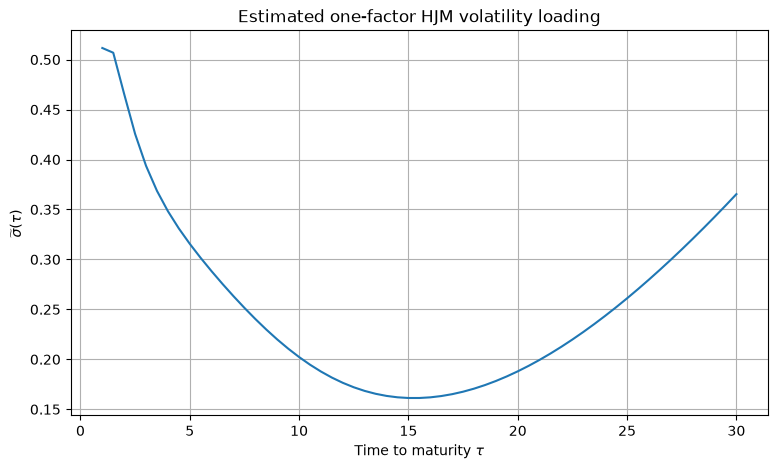

In [123]:
plt.figure(figsize=(9, 5))
plt.plot(TAUS, sigma_til_vec)
plt.xlabel(r"Time to maturity $\tau$")
plt.ylabel(r"$\widetilde{\sigma}(\tau)$")
plt.title("Estimated one-factor HJM volatility loading")
plt.grid(True)
plt.show()

In [124]:
tau_nodes = np.concatenate(([0.0], TAUS))
sigma_nodes = np.concatenate(([sigma_til_vec[0]], sigma_til_vec))

sigma_tilde = interp1d(
    tau_nodes,
    sigma_nodes,
    kind="linear",
    bounds_error=True,
)

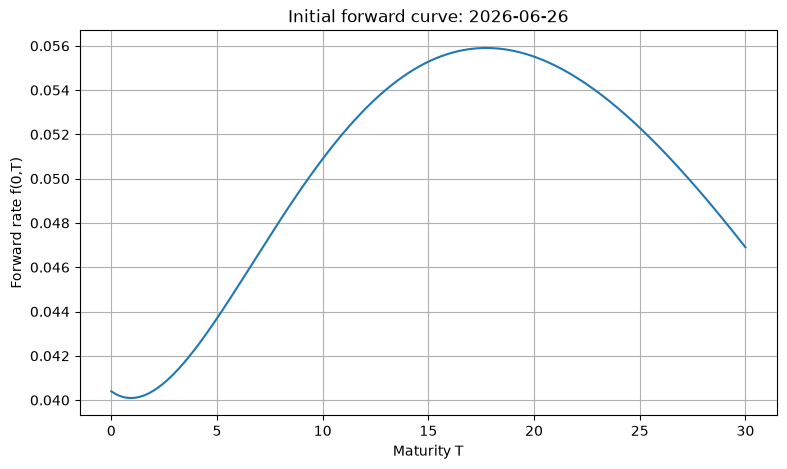

In [125]:


params_0 = df.iloc[[-1]]
calib_date = df.index[-1]

f0 = svensson_forward(params_0, T_GRID)[0] / 100.0

plt.figure(figsize=(9, 5))
plt.plot(T_GRID, f0)
plt.xlabel("Maturity T")
plt.ylabel("Forward rate f(0,T)")
plt.title(f"Initial forward curve: {calib_date.date()}")
plt.grid(True)
plt.show()


In [126]:
positive_F = F[F > 0]

print("Maximum forward rate:", np.max(F))
print("95% quantile:", np.quantile(positive_F, 0.95))
print("99% quantile:", np.quantile(positive_F, 0.99))
print("Fraction above M:", np.mean(F > M))

Maximum forward rate: 0.1031281277149495
95% quantile: 0.08334842992516579
99% quantile: 0.0890722043579851
Fraction above M: 9.305563051703569e-06


In [127]:
def s_func(t: float) -> float:
    return 1.0

sigma0 = (s_func(0.0) * sigma_tilde(T_GRID) * np.minimum(M, f0))

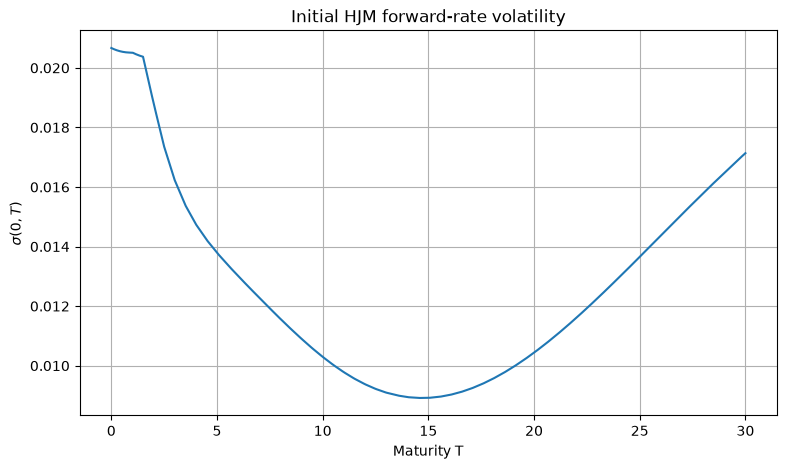

In [128]:
plt.figure(figsize=(9, 5))
plt.plot(T_GRID, sigma0)
plt.xlabel("Maturity T")
plt.ylabel(r"$\sigma(0,T)$")
plt.title("Initial HJM forward-rate volatility")
plt.grid(True)
plt.show()

In [129]:
sigma_star0 = cumulative_trapezoid(sigma0, T_GRID, initial=0.0)

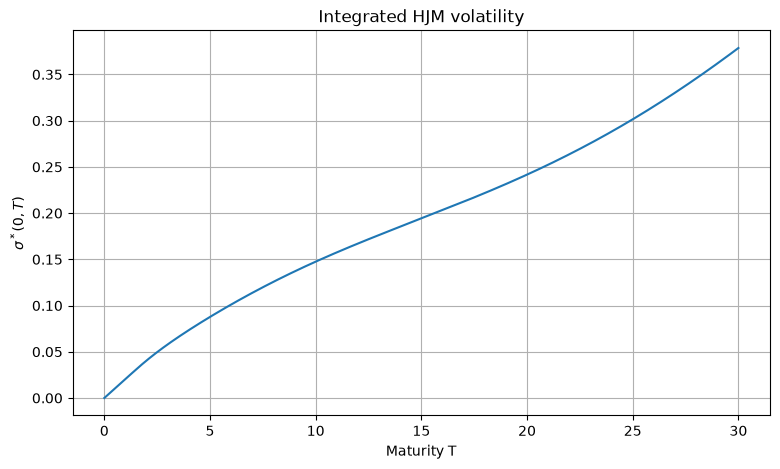

In [130]:
plt.figure(figsize=(9, 5))
plt.plot(T_GRID, sigma_star0)
plt.xlabel("Maturity T")
plt.ylabel(r"$\sigma^*(0,T)$")
plt.title("Integrated HJM volatility")
plt.grid(True)
plt.show()

### Under the risk-neutral measure, the drift term is determined by the volatility

In [131]:
drift0 = sigma0 * sigma_star0

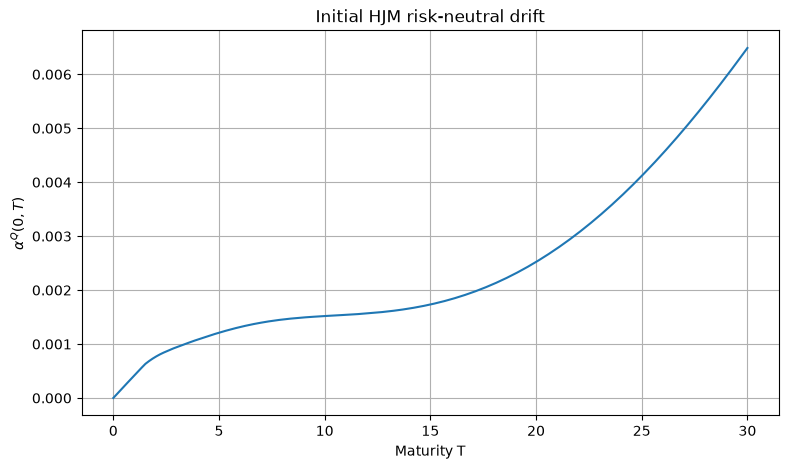

In [132]:
plt.figure(figsize=(9, 5))
plt.plot(T_GRID, drift0)
plt.xlabel("Maturity T")
plt.ylabel(r"$\alpha^Q(0,T)$")
plt.title("Initial HJM risk-neutral drift")
plt.grid(True)
plt.show()

### Since the HJM model is stochastic, we can use a Euler Step

In [133]:
rng = np.random.default_rng(42)
z = rng.standard_normal()

f1 = f0 + drift0 * SIM_DT + np.sqrt(SIM_DT) * z

### An example of moving to f1 before we loop

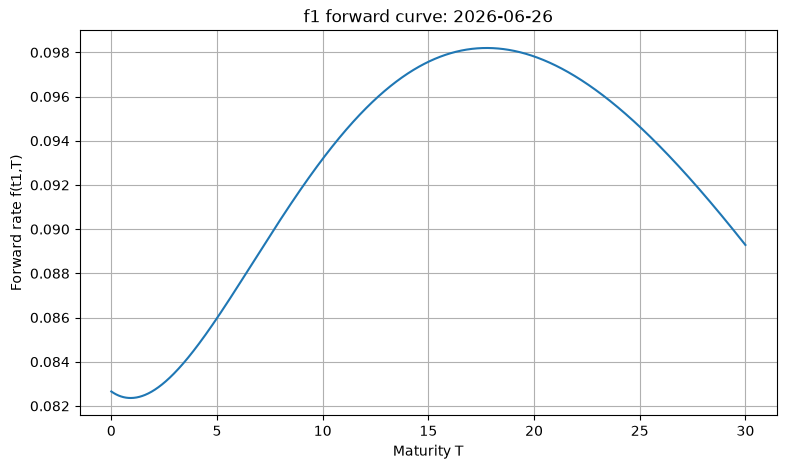

In [134]:
plt.figure(figsize=(9, 5))
plt.plot(T_GRID, f1)
plt.xlabel("Maturity T")
plt.ylabel("Forward rate f(t1,T)")
plt.title(f"f1 forward curve: {calib_date.date()}")
plt.grid(True)
plt.show()

In [135]:
# The upper bound on our range for t (Time horizon of 30 years)
SIM_HORIZON = 10.0

N_STEPS = int(round(SIM_HORIZON/SIM_DT))

curves = np.full((N_STEPS+1, len(T_GRID)), np.nan)

curves[0] = f0

rng = np.random.default_rng(42)

for n in range(N_STEPS):
    t = n * SIM_DT

    active_T = T_GRID[n:]
    active_f = curves[n, n:]

    tau = active_T - t

    sigma = sigma_tilde(tau) * np.minimum(M, active_f)

    sigma_star = cumulative_trapezoid(sigma, active_T, initial=0.0)

    drift = sigma*sigma_star

    z = rng.standard_normal()

    updated_f = active_f + drift * SIM_DT + sigma * np.sqrt(SIM_DT) * z

    curves[n+1, n+1:] = updated_f[1:]

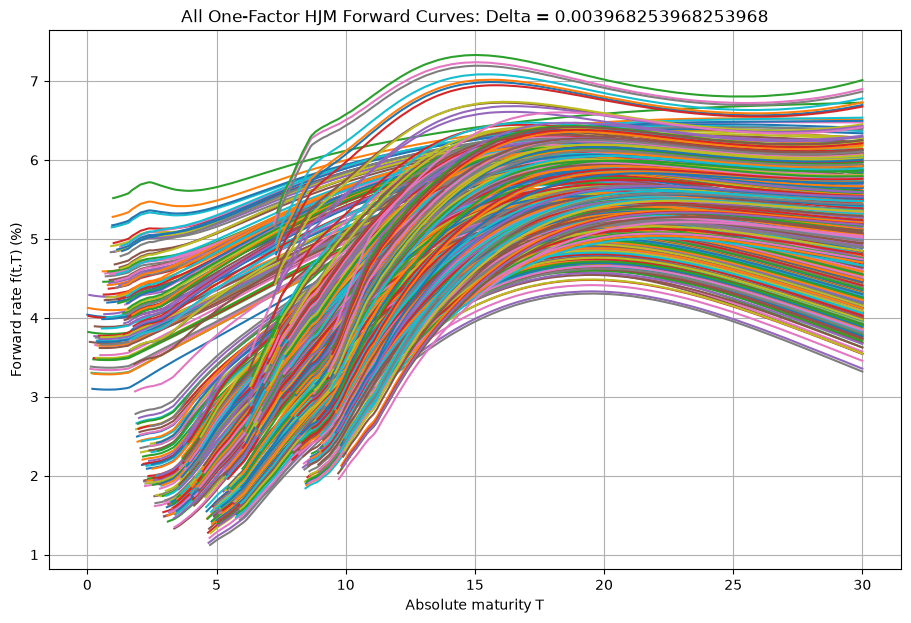

In [140]:
plt.figure(figsize=(11, 7))

for n in range(N_STEPS + 1):
    valid = np.isfinite(curves[n])

    plt.plot(
        T_GRID[valid],
        100 * curves[n, valid],
    )

plt.xlabel("Absolute maturity T")
plt.ylabel("Forward rate f(t,T) (%)")
plt.title(f"All One-Factor HJM Forward Curves: Delta = {DELTA}")
plt.grid(True)
plt.show()